Cell 1 — Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

PROJECT_ROOT = '/content/drive/MyDrive/PitWall'
DB_PATH      = f'{PROJECT_ROOT}/pitwall.db'
REPORTS_DIR  = f'{PROJECT_ROOT}/reports'
Path(REPORTS_DIR).mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SEASON  = 2024
print('Setup OK.')

Mounted at /content/drive
Setup OK.


Cell 2 — Load features + same split as baselines

In [2]:
with sqlite3.connect(DB_PATH) as conn:
    features = pd.read_sql('SELECT * FROM team_season_features', conn)

FEATURE_COLS = [
    'avg_grid', 'avg_qual_gap_to_pole', 'pole_count',
    'dnf_rate', 'avg_qual_to_race_delta',
    'races_entered', 'season',
]
TARGET = 'total_points'

train = features[features['season'] < TEST_SEASON].reset_index(drop=True)
test  = features[features['season'] == TEST_SEASON].reset_index(drop=True)

X_train, y_train = train[FEATURE_COLS].values, train[TARGET].values
X_test,  y_test  = test[FEATURE_COLS].values,  test[TARGET].values

print(f'Train: {X_train.shape}  ({train["season"].min()}–{train["season"].max()})')
print(f'Test:  {X_test.shape}   (season {TEST_SEASON})')

Train: (102, 7)  (2014–2023)
Test:  (10, 7)   (season 2024)


Cell 3 — Train Gradient Boosting Regressor

In [3]:
# Sensible defaults for small tabular regression (102 train rows).
# Shallow trees + many small steps + low learning rate to avoid overfit.
gbr = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rmse_cv = -cross_val_score(gbr, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
r2_cv   =  cross_val_score(gbr, X_train, y_train, cv=kf, scoring='r2')
mae_cv  = -cross_val_score(gbr, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error')

print(f'GBR (5-fold CV)   RMSE {rmse_cv.mean():6.1f} ± {rmse_cv.std():.1f}   '
      f'R² {r2_cv.mean():.3f} ± {r2_cv.std():.3f}   '
      f'MAE {mae_cv.mean():6.1f} ± {mae_cv.std():.1f}')

GBR (5-fold CV)   RMSE   46.6 ± 22.8   R² 0.949 ± 0.034   MAE   30.8 ± 16.3



Cell 4 — Test set evaluation

In [4]:
gbr.fit(X_train, y_train)
yhat_gbr = gbr.predict(X_test)

test_gbr = {
    'rmse': np.sqrt(mean_squared_error(y_test, yhat_gbr)),
    'r2':   r2_score(y_test, yhat_gbr),
    'mae':  mean_absolute_error(y_test, yhat_gbr),
}
print(f'GBR test {TEST_SEASON}:    RMSE {test_gbr["rmse"]:.1f}   '
      f'R² {test_gbr["r2"]:.3f}   MAE {test_gbr["mae"]:.1f}')

GBR test 2024:    RMSE 50.4   R² 0.959   MAE 39.0


Cell 5 — Permutation importance (more reliable than impurity-based)

Permutation importance (mean drop in R² when feature shuffled):
               feature  mean_drop_R2    std
              avg_grid        1.0171 0.0956
  avg_qual_gap_to_pole        0.1056 0.0103
            pole_count        0.0596 0.0082
avg_qual_to_race_delta        0.0389 0.0046
              dnf_rate        0.0031 0.0004
                season        0.0014 0.0003
         races_entered        0.0005 0.0001


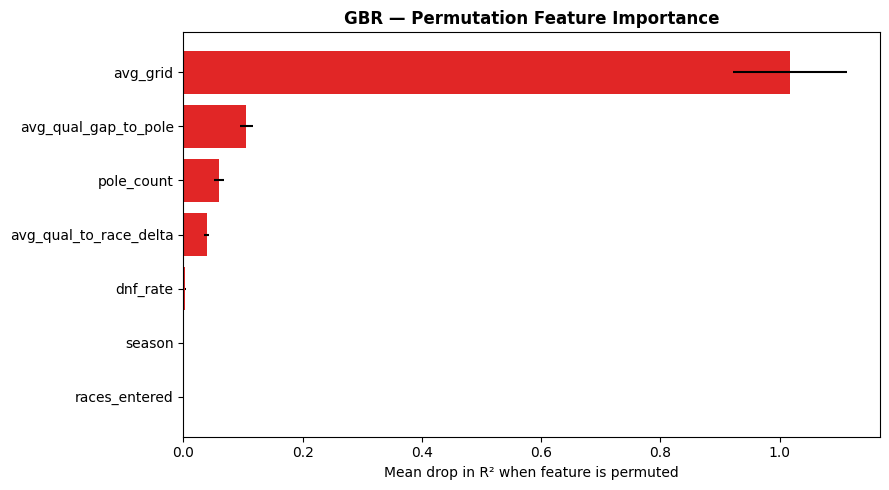

In [5]:
perm = permutation_importance(
    gbr, X_train, y_train,
    n_repeats=30, random_state=RANDOM_STATE, scoring='r2'
)
imp_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'mean_drop_R2': perm.importances_mean,
    'std': perm.importances_std,
}).sort_values('mean_drop_R2', ascending=False)

print('Permutation importance (mean drop in R² when feature shuffled):')
print(imp_df.round(4).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp_df['feature'][::-1], imp_df['mean_drop_R2'][::-1],
        xerr=imp_df['std'][::-1], color='#DC0000', alpha=0.85)
ax.set_xlabel('Mean drop in R² when feature is permuted')
ax.set_title('GBR — Permutation Feature Importance', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/sprint2_03_gbr_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Cell 6 — Full model comparison (LR / DT / GBR)

In [6]:
prior = pd.read_csv(f'{REPORTS_DIR}/sprint2_baselines_metrics.csv')

new_row = pd.DataFrame([{
    'model':     'GradientBoosting',
    'cv_rmse':   rmse_cv.mean(),
    'cv_r2':     r2_cv.mean(),
    'cv_mae':    mae_cv.mean(),
    'test_rmse': test_gbr['rmse'],
    'test_r2':   test_gbr['r2'],
    'test_mae':  test_gbr['mae'],
}])

all_models = pd.concat([prior, new_row], ignore_index=True)
print('Full Sprint 2 model comparison:')
print(all_models.round(3).to_string(index=False))

all_models.to_csv(f'{REPORTS_DIR}/sprint2_all_models_metrics.csv', index=False)
print(f'\nSaved → {REPORTS_DIR}/sprint2_all_models_metrics.csv')

Full Sprint 2 model comparison:
           model  cv_rmse  cv_r2  cv_mae  test_rmse  test_r2  test_mae
LinearRegression   53.554  0.933  43.279     50.725    0.959    38.409
DecisionTree d=5   71.606  0.885  45.508     96.312    0.851    64.480
GradientBoosting   46.610  0.949  30.793     50.364    0.959    38.965

Saved → /content/drive/MyDrive/PitWall/reports/sprint2_all_models_metrics.csv


Cell 7 — GBR predictions on held-out 2024

GBR predictions on held-out 2024:
 season           name constructor_id  total_points  gbr_pred  gbr_residual
   2024        McLaren        mclaren         609.0     577.5          31.5
   2024        Ferrari        ferrari         595.0     485.5         109.5
   2024       Red Bull       red_bull         537.0     624.4         -87.4
   2024       Mercedes       mercedes         433.0     405.6          27.4
   2024   Aston Martin   aston_martin          94.0     134.7         -40.7
   2024 Alpine F1 Team         alpine          63.0      48.8          14.2
   2024   Haas F1 Team           haas          51.0      61.2         -10.2
   2024     RB F1 Team             rb          40.0      80.1         -40.1
   2024       Williams       williams          17.0      29.6         -12.6
   2024         Sauber         sauber           4.0      20.0         -16.0


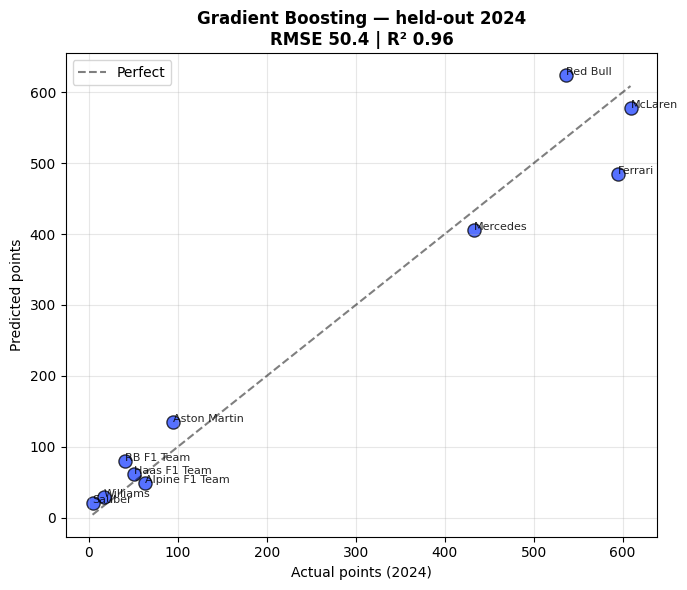

In [7]:
preds_gbr = test[['season', 'name', 'constructor_id', TARGET]].copy()
preds_gbr['gbr_pred']     = yhat_gbr.round(1)
preds_gbr['gbr_residual'] = (preds_gbr[TARGET] - preds_gbr['gbr_pred']).round(1)
preds_gbr = preds_gbr.sort_values(TARGET, ascending=False).reset_index(drop=True)

print(f'GBR predictions on held-out {TEST_SEASON}:')
print(preds_gbr.to_string(index=False))

# Quick scatter
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(preds_gbr[TARGET], preds_gbr['gbr_pred'], s=90, alpha=0.75,
           color='#1E41FF', edgecolor='k')
lo, hi = preds_gbr[TARGET].min(), preds_gbr[TARGET].max()
ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, label='Perfect')
for _, row in preds_gbr.iterrows():
    ax.annotate(row['name'], (row[TARGET], row['gbr_pred']), fontsize=8, alpha=0.85)
ax.set_xlabel(f'Actual points ({TEST_SEASON})')
ax.set_ylabel('Predicted points')
ax.set_title(f'Gradient Boosting — held-out {TEST_SEASON}\n'
             f'RMSE {test_gbr["rmse"]:.1f} | R² {test_gbr["r2"]:.2f}',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/sprint2_04_gbr_test.png', dpi=150, bbox_inches='tight')
plt.show()

preds_gbr.to_csv(f'{REPORTS_DIR}/sprint2_gbr_test_preds.csv', index=False)

Cell 8 — Save the trained model artifact

In [8]:
import joblib
MODELS_DIR = f'{PROJECT_ROOT}/models'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)

joblib.dump({
    'model': gbr,
    'features': FEATURE_COLS,
    'target': TARGET,
    'train_seasons': sorted(train['season'].unique().tolist()),
    'test_season': TEST_SEASON,
    'metrics': {
        'cv_rmse': float(rmse_cv.mean()), 'cv_r2': float(r2_cv.mean()),
        'test_rmse': float(test_gbr['rmse']), 'test_r2': float(test_gbr['r2']),
    },
}, f'{MODELS_DIR}/gbr_total_points_v1.joblib')

print(f'Model saved → {MODELS_DIR}/gbr_total_points_v1.joblib')

Model saved → /content/drive/MyDrive/PitWall/models/gbr_total_points_v1.joblib
